In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chi2, kstwobign, norm
from math import gcd
from sympy import primefactors
from itertools import product, islice
from scipy.stats import chisquare, kstest

# Part 1

In [4]:
def histogram(x, bins=10, text="Histogram of randomly generated numbers by LGC"):
    plt.hist(x, bins=bins)
    plt.title(text)
    plt.show()

In [5]:
def linear_congruential_generator(x0, a, c, M, n = 10000):
    n_array = np.zeros(n, dtype=np.int32)
    n_array[0] = x0 % M
    
    for i in range(1, n):
        n_array[i] = (a * n_array[i-1] + c) % M
    
    return n_array

def hull_dobell(a, c, M):
    # Condition 1
    cond1 = gcd(M, c) == 1
    
    # Condition 2
    primes = primefactors(M)
    cond2 = all((a - 1) % p == 0 for p in primes)
    
    # Condition 3
    cond3 = ((M % 4 != 0) or ((a - 1) % 4 == 0))
    
    return cond1 and cond2 and cond3

In [6]:
def chi_square_test(x, M):
    n = len(x)
    df = M - 1
    p_i = 1 / M
    
    n_observed = np.bincount(x, minlength=M)
    n_expected = (n * p_i) * np.ones(M)
    T = np.sum((n_observed - n_expected) **2 / n_expected)
    p_value = 1 - chi2.cdf(T, df)
        
    return T, p_value

def kolmogorov_smirnov_test(x, M):
    n = len(x)
    p_i = 1 / M
    
    F_n_x = np.cumsum(np.bincount(x, minlength=M)) / n #Empircal cdf

    F_x = np.cumsum(p_i * np.ones(M)) # Theoretical CDF (uniform)
    
    D_n = np.max(np.abs(F_n_x - F_x)) # KS statistic
    p_value = kstwobign.sf(np.sqrt(n) * D_n)
    
    return D_n, p_value
    
def wald_wolfowitz_test(x):
    median = np.median(x)
    signs = x > median
    
    T = 1 # Test statistc / total number of runs
    for i in range(1, len(signs)):
        if signs[i] == signs[i-1]:
            continue
        else:
            T += 1
        
    n1 = np.sum(signs)
    n2 = len(x) - n1
    
    mu_p = 2 * (n1*n2 / (n1 + n2)) + 1
    sigma_p = 2*n1*n2*(2*n1*n2 - n1 - n2) / ((n1+n2)**2 * (n1+n2-1))
    
    p_value = 1- norm.cdf(T, loc=mu_p, scale=sigma_p )
    
    return T, p_value

def up_down_test(data):
    n = len(data)
    comparisons = [1 if data[i+1] > data[i] else -1 for i in range(n-1)]
    
    runs = 1
    for i in range(1, len(comparisons)):
        if comparisons[i] != comparisons[i-1]:
            runs += 1
            
    z = (runs - ((2*n - 1) / 3)) / (((16*n - 29) / 90)**0.5)
    return z

def knuth_run_length_test(data):
    n = len(data)
    run_lengths = []
    current_len = 1
    for i in range(len(data) - 1):
        if data[i+1] > data[i]:
            current_len += 1
        else:
            run_lengths.append(min(current_len, 6))
            current_len = 1

    run_lengths.append(min(current_len, 6))

    R = np.zeros(6)
    for x in run_lengths:
        R[x - 1] += 1

    A = np.array([
        [4529.4, 9044.9, 13568, 18091, 22615, 27892],
        [9044.9, 18097, 27139, 36187, 45234, 55789],
        [13568, 27139, 40721, 54281, 67852, 83685],
        [18091, 36187, 54281, 72414, 90470, 111580],
        [22615, 45234, 67852, 90470, 113262, 139476],
        [27892, 55789, 83685, 111580, 139476, 172860]
    ])
    
    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    diff = R - (n * B)
    z_stat = (1 / (n - 6)) * np.dot(diff.T, np.dot(A, diff))

    return z_stat
    
def correlation_test(x, h_max=3, print_values=False):
    x = np.array(x)
    correlations = np.zeros(h_max + 1)
    
    for h in range(0, h_max + 1):
        if h == 0:
            correlations[0] = 1.0 
        else:
            correlations[h] = np.corrcoef(x[:-h], x[h:])[0, 1]
    
    if print_values:
        for h, c in enumerate(correlations):
            print(f"Lag {h}: {c:.4f}")
    
    return correlations

In [7]:
def statistical_properties(x, M, bins=10):
    histogram(x, bins=bins)
    print(f"Range: [{np.min(x)},{np.max(x)}]")
    print("Mean:", np.mean(x))
    print(f"Standard deviation: {np.std(x):.3f}")

    print("Chi square: ", end="")
    print(chi_square_test(x, M))

    print("Kolmogorov: ", end="")
    print(kolmogorov_smirnov_test(x, M))

    print("Wald: ", end="")
    print(wald_wolfowitz_test(x))

    print("up down: ", end="")
    print(up_down_test(x))

    print("knuth: ", end="")
    print(knuth_run_length_test(x))

    correlation_test(x, print_values=True)

True


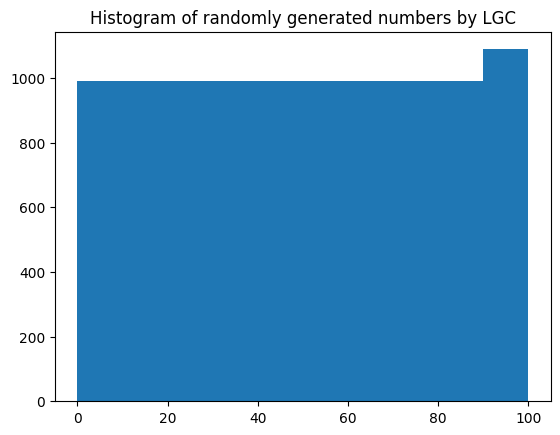

Range: [0,100]
Mean: 49.996
Standard deviation: 29.156
Chi square: (np.float64(0.010000000000000007), np.float64(1.0))
Kolmogorov: (np.float64(8.910891089110307e-05), np.float64(1.0))
Wald: (1783, np.float64(0.9010201468208543))
up down: -115.82891677493784
knuth: 9246575.697102439
Lag 0: 1.0000
Lag 1: 0.5129
Lag 2: 0.1210
Lag 3: -0.1753


In [8]:
x0, a, c, M = 10, 102, 9, 101
print(hull_dobell(a, c, M))

U_i = linear_congruential_generator(x0, a, c, M, n = 10000)
statistical_properties(U_i, M, bins=10)

/var/folders/z1/367m0gln0yl832m19156fj4h0000gn/T/ipykernel_51289/3727143981.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 1200x500 with 0 Axes>

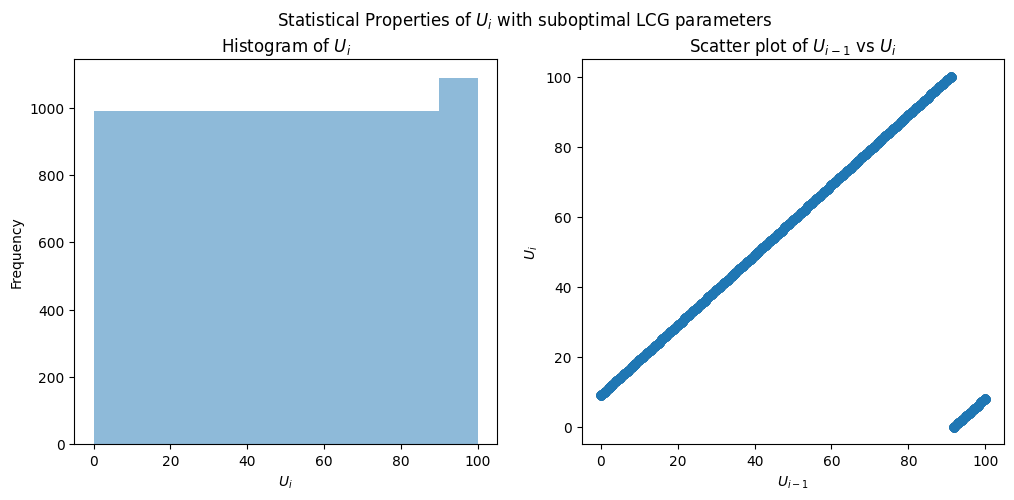

In [9]:
plt.figure(figsize=(12, 5))
fig, ax = fig, axs = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(U_i, bins=10, alpha=0.5, histtype='bar')
ax[0].set_title("Histogram of $U_i$")
ax[0].set_xlabel("$U_i$")
ax[0].set_ylabel("Frequency")

U_i_lagged = U_i[1:]
U_i_original = U_i[:-1]
ax[1].scatter(U_i_original, U_i_lagged, alpha=0.5)
ax[1].set_title("Scatter plot of $U_{i-1}$ vs $U_i$")
ax[1].set_xlabel("$U_{i-1}$")
ax[1].set_ylabel("$U_i$")

fig.suptitle('Statistical Properties of $U_i$ with suboptimal LCG parameters')

fig.show()

In [10]:
a_values = np.arange(10**2, 10**3)[::-1]
c_values = np.arange(10**2, 10**3)[::-1]
M_values = np.arange(10**2, 10**3)[::-1]

parameter_grid = list(islice(
    ((a, c, M) 
     for a, c, M in product(a_values, c_values, M_values)
     if hull_dobell(a, c, M)),
    10
))

Testing parameters: a=999, c=993, M=499


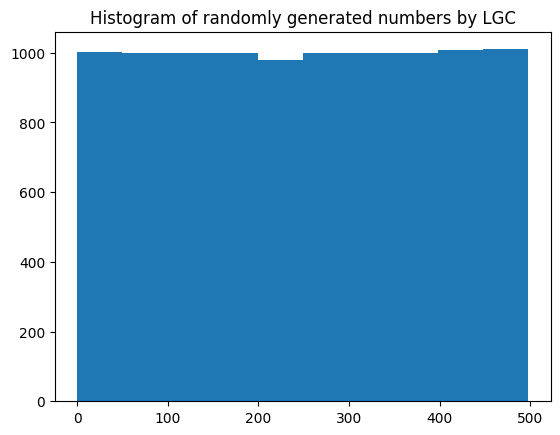

Range: [0,498]
Mean: 249.3571
Standard deviation: 144.197
Chi square: (np.float64(0.9580000000000003), np.float64(1.0))
Kolmogorov: (np.float64(0.0015232464929866296), np.float64(1.0))
Wald: (202, np.float64(0.972557915656503))
up down: -153.32902273149278
knuth: 52516.73337499756
Lag 0: 1.0000
Lag 1: 0.9401
Lag 2: 0.8820
Lag 3: 0.8251


In [11]:
# Test the first parameter set
a, c, M = parameter_grid[-1]
print(f"Testing parameters: a={a}, c={c}, M={M}")
x = linear_congruential_generator(1, a, c, M)
statistical_properties(x, M, bins=10)

# Part 2

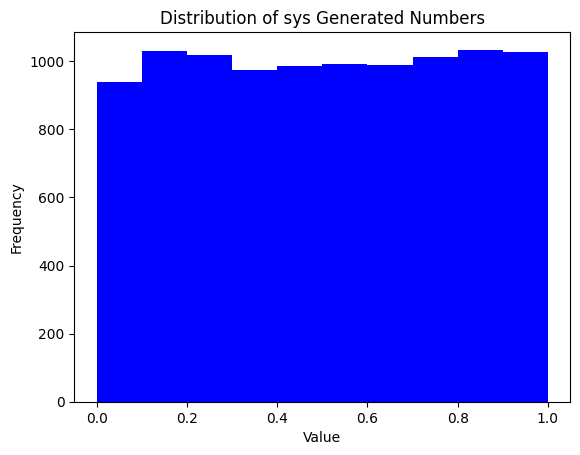

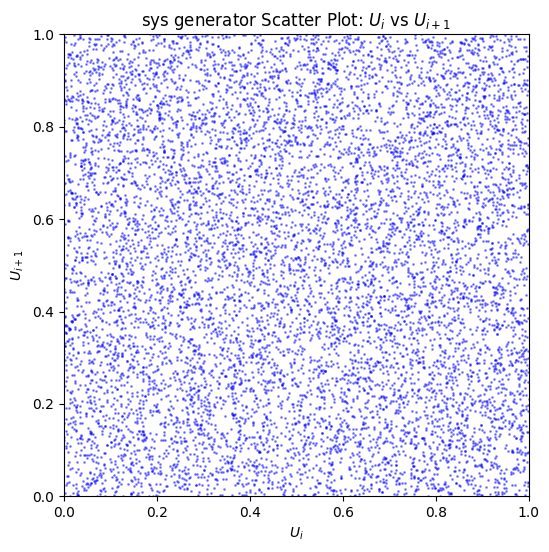

Chi Squared:    X^2=8.312, p=0.5030355818491519
Kolmogorov:     D=0.00946863068352266, p=0.3292976643518214
Wald-Wolfowitz: z=(5055, np.float64(0.4913826550796293))
Up-Down:        z=-1.0041141590728329
Knuth:          χ^2=2.2171433522747264
Lag 0: 1.0000
Lag 1: -0.0089
Lag 2: 0.0084
Lag 3: -0.0225


array([ 1.        , -0.00887566,  0.00837362, -0.02246225])

In [12]:
n = 10000

system_numbers = np.random.uniform(size=n)

plt.hist(system_numbers, bins=10, range=(0,1), color='blue')
plt.title("Distribution of sys Generated Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(system_numbers[:-1], system_numbers[1:], s=1, alpha=0.4, color='blue')
plt.title("sys generator Scatter Plot: $U_i$ vs $U_{i+1}$")
plt.xlabel("$U_i$"); plt.ylabel("$U_{i+1}$")
plt.xlim(0,1); plt.ylim(0,1)
plt.show()

chi_sq, p_value = chisquare(f_obs=np.histogram(system_numbers, bins=10, range=(0,1))[0], f_exp=n/10)
print(f"Chi Squared:    X^2={chi_sq}, p={p_value}")
d_statistic, p_value = kstest(system_numbers, 'uniform')
print(f"Kolmogorov:     D={d_statistic}, p={p_value}")
print(f"Wald-Wolfowitz: z={wald_wolfowitz_test(system_numbers)}")
print(f"Up-Down:        z={up_down_test(system_numbers)}")
print(f"Knuth:          χ^2={knuth_run_length_test(system_numbers)}")
correlation_test(system_numbers, h_max=3, print_values=True)

# Part 3

/var/folders/z1/367m0gln0yl832m19156fj4h0000gn/T/ipykernel_51289/3193824210.py:6: RuntimeWarning: overflow encountered in scalar multiply
  n_array[i] = (a * n_array[i-1] + c) % M


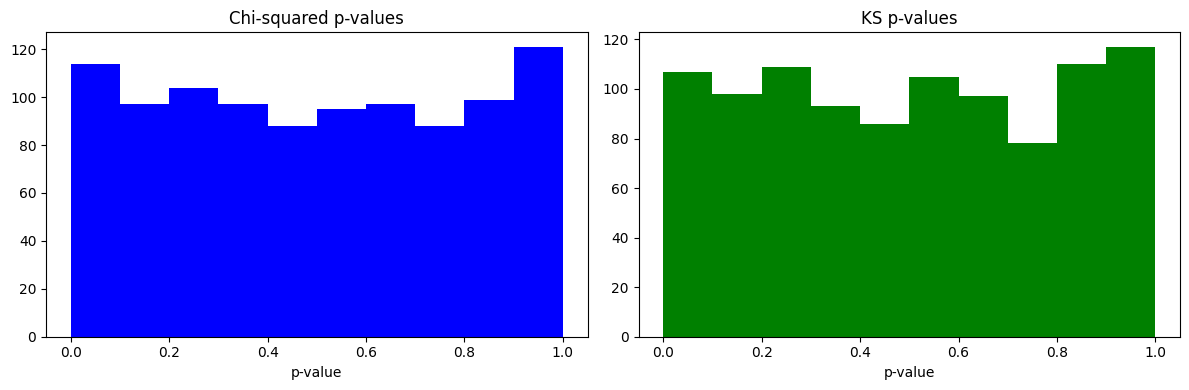

In [ ]:
# One sample containing 10000 numbers is not sufficient to make strong conclusions.
# So we performed the test 1000 times using different start numbers to verify that the 
# p-values are uniformly distributed from 0 to 1.

# We also used a different generator here

a = 16387
c = 1
M = 2**22

n_samples = 10000
chi_pvals, ks_pvals = [], []


for start_n in range(1000):
    raw_nums = linear_congruential_generator(start_n, a, c, M, n_samples)
    nums = np.array(raw_nums) / M 
    
    counts, _ = np.histogram(nums, bins=10, range=(0, 1))
    
    f_exp = np.full(10, len(nums) / 10)
    
    _, cp = chisquare(f_obs=counts, f_exp=f_exp)
    d, kp = kstest(nums, 'uniform')
    
    chi_pvals.append(cp)
    ks_pvals.append(kp)


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(chi_pvals, bins=10, range=(0,1), color='blue')
plt.title("Chi-squared p-values")
plt.xlabel("p-value")
plt.subplot(1, 2, 2)
plt.hist(ks_pvals, bins=10, range=(0,1), color='green')
plt.title("KS p-values")
plt.xlabel("p-value")
plt.tight_layout()
plt.show()

# Initially We performed 100 iterations where some minor irregularities could be
# observed, including a small peak around 0.2-0.3 when using chi-square. With 100
# runs involved it is normal since these are just random deviations.
# When repeating the procedure with 1000 start numbers we get a smoother graph,
# proving that there are no problems with the generator and those deviations
# occurred because of the low number of runs.